In [2]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [3]:
def get_var_size():
    # Get all variables in the current namespace
    variables = {name: value for name, value in globals().items() if not name.startswith("__")}

    # Sort variables by size
    sorted_vars = sorted(variables.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

    # Print variable sizes
    for name, value in sorted_vars:
        print(f"{name}: {sys.getsizeof(value) / 1024:.2f} KB")

In [4]:
fly_num = '208'
fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
filter_name = 'functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5'
STA_path = os.path.join(fly_path, 'temp_filter', filter_name)
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'

In [5]:
for file in os.listdir(later_dir):
    print(file)

total
flat
inc
figs
single_fly_supervox
dec
clustering


In [ ]:
%%time
fly_list=['208', '209', '210', '217', '218', '226', '227', '228', '233', '234', '239', '240', '241', '242', '249', '250']
# fly_list=['208', '209', '210', '217', '234', '239', '240', '241'] #best flies based on correlation QC

behaviors = ['inc', 'dec', 'flat', 'total']
cc=2
event=True
event_name='best'

for behavior in behaviors:
    for fly in fly_list:
        fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}'
        files = os.listdir(os.path.join(fly_path, 'temp_filter'))
        if event:
            file = f"functional_channel_{cc}_moco_warp_blurred_hpf_dff_filtered_{behavior}_{event_name}.h5"
            new_file = f"{fly}_tf_{behavior}_{cc}_{event_name}.h5"
        else:
            file = f"functional_channel_{cc}_moco_warp_blurred_hpf_dff_filtered_{behavior}.h5"
            new_file = f"{fly}_tf_{behavior}_{cc}.h5"
        if file in files:
            source = os.path.join(fly_path, 'temp_filter', file)
            
    #         print(new_file)
            destination = os.path.join(later_dir, behavior, new_file)
            if os.path.exists(destination)==False: 
                dest = shutil.copyfile(source, destination)
            print("Destination path:", destination)

        else:
            print("Not there yet!")
    

Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/208_tf_inc_2_best.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/209_tf_inc_2_best.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/210_tf_inc_2_best.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/217_tf_inc_2_best.h5


In [12]:
for behavior in behaviors:
    behave_dir = os.path.join(later_dir, behavior)
    for file in os.listdir(behave_dir):
        if '_tf_' in file:
            print(file)

217_tf_inc.h5
208_tf_inc.h5
250_tf_inc.h5
226_tf_inc.h5
242_tf_inc.h5
227_tf_inc.h5
240_tf_inc.h5
228_tf_inc.h5
234_tf_inc.h5
233_tf_inc.h5
209_tf_inc.h5
249_tf_inc.h5
210_tf_inc.h5
241_tf_inc.h5
218_tf_inc.h5
239_tf_inc.h5
234_tf_dec.h5
242_tf_dec.h5
249_tf_dec.h5
240_tf_dec.h5
218_tf_dec.h5
228_tf_dec.h5
233_tf_dec.h5
210_tf_dec.h5
250_tf_dec.h5
241_tf_dec.h5
209_tf_dec.h5
217_tf_dec.h5
208_tf_dec.h5
226_tf_dec.h5
227_tf_dec.h5
239_tf_dec.h5
217_tf_flat.h5
233_tf_flat.h5
208_tf_flat.h5
239_tf_flat.h5
228_tf_flat.h5
240_tf_flat.h5
218_tf_flat.h5
249_tf_flat.h5
242_tf_flat.h5
210_tf_flat.h5
250_tf_flat.h5
226_tf_flat.h5
209_tf_flat.h5
227_tf_flat.h5
241_tf_flat.h5
234_tf_flat.h5
239_tf_total.h5
234_tf_total.h5
210_tf_total.h5
233_tf_total.h5
218_tf_total.h5
241_tf_total.h5
217_tf_total.h5
226_tf_total.h5
250_tf_total.h5
228_tf_total.h5
227_tf_total.h5
242_tf_total.h5
249_tf_total.h5
208_tf_total.h5
240_tf_total.h5
209_tf_total.h5


In [7]:
inc_dir='/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc'
dec_dir='/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/dec'
flat_dir='/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/flat'
total_dir='/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total'

In [32]:
%%time
behave_dir=total_dir

range_start=-500; range_end=1900; steps=100
STA=[]  

for file in os.listdir(behave_dir):
        load_path = os.path.join(behave_dir,file)
        print(load_path)
        temp=[]
        with h5py.File(load_path, 'r+') as hf:    
                ts = hf['time_stamps'][:]
                brain = hf['brain']
                dimst = np.shape(ts)
                dims = np.shape(brain)
                print(f'Brain shape: {dims}, time stamp shape: {dimst}')
                for i in range(range_start, range_end, steps):
                    end = i + steps if i + steps < range_end else range_end
                    mask = (ts > i) & (ts < end)
#                     print(np.shape(mask))
                    result = np.nanmean(np.where(mask, brain, np.nan),axis=-1)
#                     print(np.shape(result))
                    temp.append(result)
#                     print(np.count_nonzero(~np.isnan(result[250,50,50,:])))
#                     bined.append(result)
#                     del result
#                     gc.collect()
        print(np.shape(temp))
        STA.append(temp)
#         print(f'STA is {np.shape(STA)}')
        
#     print(np.shape(bined))
#     total_binned = np.nanmean(binned, axis=-1)
#     STA.append(total_binned)
STA=np.asarray(np.nanmean(STA, axis=0)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/239_tf_total.h5
Brain shape: (314, 146, 91, 1035), time stamp shape: (314, 146, 91, 1035)
(1, 314, 146, 91)
STA is (1, 1, 314, 146, 91)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/234_tf_total.h5
Brain shape: (314, 146, 91, 1030), time stamp shape: (314, 146, 91, 1030)
(1, 314, 146, 91)
STA is (2, 1, 314, 146, 91)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/210_tf_total.h5
Brain shape: (314, 146, 91, 1025), time stamp shape: (314, 146, 91, 1025)


/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning:

Mean of empty slice



(1, 314, 146, 91)
STA is (3, 1, 314, 146, 91)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/233_tf_total.h5
Brain shape: (314, 146, 91, 1035), time stamp shape: (314, 146, 91, 1035)
(1, 314, 146, 91)
STA is (4, 1, 314, 146, 91)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/218_tf_total.h5
Brain shape: (314, 146, 91, 1039), time stamp shape: (314, 146, 91, 1039)


KeyboardInterrupt: 

In [27]:
print(np.shape(STA))
mean_test=np.nanmean(STA, axis=0)

(336, 314, 146, 91)


In [30]:
24*14

336

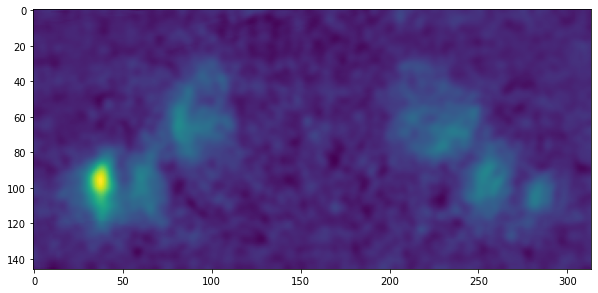

In [25]:
plt.figure(figsize=(10,10))
plt.imshow(mean_test[...,50].T)